# **Disciplina: DS-006**
**Aula: 02**

Topicos abordados:

* POINT; shapefile
* Usando shape
* Plot map usando bolhas
* Variações de visualização de mapas

In [33]:
"""
Bibliotecas a serem utilizadas
"""
import pandas as pd

Dados relacionados a **Febre Amarela em humanos e primatas não-humanos - 1994 a 2023**

Dataset a ser utilizado foi obtido em: https://opendatasus.saude.gov.br/dataset/febre-amarela-em-humanos-e-primatas-nao-humanos

Descrição dos dataset: https://s3.sa-east-1.amazonaws.com/ckan.saude.gov.br/Febre+Amarela/Dicionario+de+variaveis.pdf

In [34]:
url = 'https://s3.sa-east-1.amazonaws.com/ckan.saude.gov.br/Febre+Amarela/fa_casoshumanos_1994-2023.csv'
df = pd.read_csv(url,encoding = "ISO-8859-1", sep=';')

**Conhecendo o dataset**

In [35]:
df.head()
#Descrição dos dataset: https://s3.sa-east-1.amazonaws.com/ckan.saude.gov.br/Febre+Amarela/Dicionario+de+variaveis.pdf

,ID,MACRORREG_LPI,COD_UF_LPI,UF_LPI,COD_MUN_LPI,MUN_LPI,SEXO,IDADE,DT_IS,SE_IS,MES_IS,ANO_IS,MONITORAMENTO_IS,OBITO,DT_OBITO
0,1,N,14,RR,140005.0,ALTO ALEGRE,M,NaN,29/11/1994,48.0,11.0,1994,1994/1995,SIM,01/12/1994
1,2,N,14,RR,140045.0,PACARAIMA,M,19,19/02/1995,8.0,2.0,1995,1994/1995,NÃO,NaN
2,3,NE,21,MA,210060.0,AMARANTE DO MARANHÃO,M,32,01/04/1995,13.0,4.0,1995,1994/1995,IGN,NaN
3,4,NE,21,MA,210060.0,AMARANTE DO MARANHÃO,M,33,03/04/1995,14.0,4.0,1995,1994/1995,SIM,09/04/1995
4,5,N,15,PA,150270.0,CONCEIÇÃO DO ARAGUAIA,M,26,12/04/1995,15.0,4.0,1995,1994/1995,SIM,20/04/1995


In [36]:
#Substituindo o NaN e valores vazios por 0 e removendo valores como string

# Replace NaN and empty values with 0
df["IDADE"] = df["IDADE"].fillna(0)
df["IDADE"] = df["IDADE"].replace('', 0)

# Remove string values (if any) and convert to numeric
df["IDADE"] = pd.to_numeric(df["IDADE"], errors='coerce').fillna(0).astype(int)
df["IDADE"].mean()

42.53901734104046

In [37]:
# Ordenando o dataframe
df_ordenado = df.sort_values('UF_LPI')
df_ordenado.head()

# Conhecendo os códigos do municipios: https://www.ibge.gov.br/explica/codigos-dos-municipios.php

,ID,MACRORREG_LPI,COD_UF_LPI,UF_LPI,COD_MUN_LPI,MUN_LPI,SEXO,IDADE,DT_IS,SE_IS,MES_IS,ANO_IS,MONITORAMENTO_IS,OBITO,DT_OBITO
2735,2736,N,12,AC,120001.0,ACRELÂNDIA,M,16,30/01/2020,5.0,1.0,2020,2019/2020,SIM,10/02/2020
216,217,N,12,AC,120038.0,PLÁCIDO DE CASTRO,M,21,29/06/2000,26.0,6.0,2000,1999/2000,NÃO,NaN
336,337,N,13,AM,130440.0,URUCURITUBA,F,16,13/05/2003,20.0,5.0,2003,2001/2002,NÃO,NaN
28,29,N,13,AM,130353.0,PRESIDENTE FIGUEIREDO,F,17,28/02/1998,8.0,2.0,1998,1997/1998,NÃO,NaN
2727,2728,N,13,AM,130130.0,CODAJÁS,M,21,28/02/2019,9.0,2.0,2019,2018/2019,NÃO,NaN


In [38]:
"""
Seleção de colunas para manipulação dos dados
Criando um novo data frame usando df_ordenado que contenha as colunas:
UF_LPI, MUN_LPI, SEXO, IDADE, ANO_IS, OBITO e redefinindo o index do data frame
"""

novo_df = df_ordenado[['UF_LPI', 'MUN_LPI', 'SEXO', 'IDADE', 'ANO_IS', 'OBITO']].reset_index(drop=True)
novo_df.head()


,UF_LPI,MUN_LPI,SEXO,IDADE,ANO_IS,OBITO
0,AC,ACRELÂNDIA,M,16,2020,SIM
1,AC,PLÁCIDO DE CASTRO,M,21,2000,NÃO
2,AM,URUCURITUBA,F,16,2003,NÃO
3,AM,PRESIDENTE FIGUEIREDO,F,17,1998,NÃO
4,AM,CODAJÁS,M,21,2019,NÃO


In [39]:
# Conhecendo a biblioteca GEOBR: https://ipeagit.github.io/geobr/articles/python-intro/py-intro-to-geobr.html
!pip install geobr

In [40]:
import matplotlib.pyplot as plt
%matplotlib inline

---
## **Início da AULA 003**

---

In [41]:
# Exemplos de objetos geométricos
import geopandas
# TODO import GeoSeries e Polygon
from geopandas import GeoSeries
from shapely.geometry import Polygon

In [42]:
# TODO: Criando objetos geométricos e series
p1 = Polygon([(0, 0), (1, 0), (1, 1)])
p2 = Polygon([(2, 0), (3, 0), (3, 1), (2, 1)])

p3 = Polygon([(5, 0), (6, 0), (6.5, 1), (6, 2), (5, 2), (4.5, 1)])

g = GeoSeries([p1, p2, p3])

<Axes: >

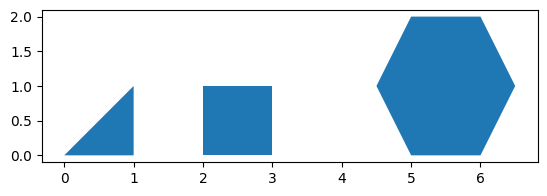

In [43]:
# TODO: plot os objetos geometricos
g.plot()

In [44]:
g

,0
0,"POLYGON ((0.00000 0.00000, 1.00000 0.00000, 1...."
1,"POLYGON ((2.00000 0.00000, 3.00000 0.00000, 3...."
2,"POLYGON ((5.00000 0.00000, 6.00000 0.00000, 6...."


In [12]:
# TODO: Obtenha o centroid como POINT


centroid = g.centroid
print(centroid)


POINT (0.6666666666666666 0.3333333333333333)


# **Usando dataset de shapes**

In [47]:
# TODO: Teste datasets com shapes
!pip install geodatasets

In [48]:
import geodatasets

In [54]:
# health
# https://geodatasets.readthedocs.io/en/latest/introduction.html
# TODO: Ler um shape
health = geopandas.read_file(geodatasets.get_path("geoda.health"))

Extracting 'income_diversity/income_diversity.shp' from '/root/.cache/geodatasets/income_diversity.zip' to '/root/.cache/geodatasets/income_diversity.zip.unzip'
Extracting 'income_diversity/income_diversity.dbf' from '/root/.cache/geodatasets/income_diversity.zip' to '/root/.cache/geodatasets/income_diversity.zip.unzip'
Extracting 'income_diversity/income_diversity.shx' from '/root/.cache/geodatasets/income_diversity.zip' to '/root/.cache/geodatasets/income_diversity.zip.unzip'
Extracting 'income_diversity/income_diversity.prj' from '/root/.cache/geodatasets/income_diversity.zip' to '/root/.cache/geodatasets/income_diversity.zip.unzip'


In [55]:
health.head()

,cartodb_id,countyfp,statefp,statename,countyname,countyfips,tractname,ratio,statemhir,tractmhir,...,Diversity,BlackorA,AmericanI,Asianalon,NativeHaw,TwoorMor,Hispanico,Whitealon,county,geometry
0,80.0,057,12,Florida,"Hillsborough County, Florida",12057.0,"Census Tract 108.14, Hillsborough County, Florida",0.575,47212.0,27143.0,...,0.626423,17.4,0.5,3.9,0.1,2.5,26.0,52.3,County,"POLYGON ((-82.43746 27.86702, -82.43545 27.884..."
1,398.0,213,48,Texas,"Henderson County, Texas",48213.0,"Census Tract 9509.01, Henderson County, Texas",0.752,52576.0,39558.0,...,0.350927,6.6,0.8,0.6,0.1,1.6,11.8,79.4,County,"POLYGON ((-96.45414 32.35168, -96.45233 32.352..."
2,409.0,409,48,Texas,"San Patricio County, Texas",48409.0,"Census Tract 102.01, San Patricio County, Texas",0.708,52576.0,37231.0,...,0.525780,2.1,0.9,1.1,0.1,1.4,55.4,40.8,County,"POLYGON ((-97.24472 27.86006, -97.24462 27.859..."
3,647.0,005,24,Maryland,"Baltimore County, Maryland",24005.0,"Census Tract 4209, Baltimore County, Maryland",0.485,74149.0,35996.0,...,0.552251,27.5,0.4,5.7,0.1,2.3,4.8,60.5,County,"POLYGON ((-76.89556 39.42949, -76.89497 39.430..."
4,712.0,031,13,Georgia,"Bulloch County, Georgia",13031.0,"Census Tract 1104.03, Bulloch County, Georgia",0.367,49342.0,18103.0,...,0.497338,28.9,0.4,1.6,0.1,1.6,3.6,64.6,County,"POLYGON ((-82.02684 32.55516, -82.00150 32.606..."


<Axes: >

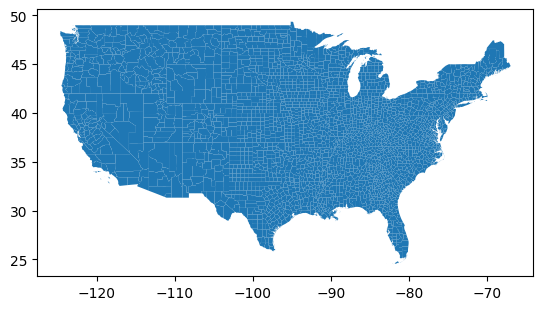

In [56]:
health.plot()

# **Usando SHAPEFILE**

In [57]:
import gdown

In [58]:
# https://ppbio.inpa.gov.br/mapas
url = "https://drive.google.com/drive/folders/1IYfX8I_r9I2xp_4KwNXoWSXKzp_Reo8g?usp=sharing"
gdown.download_folder(url, quiet=True, use_cookies=False)


['/content/shapefile/estrada.dbf',
 '/content/shapefile/estrada.sbn',
 '/content/shapefile/estrada.sbx',
 '/content/shapefile/estrada.shp',
 '/content/shapefile/estrada.shx']

In [59]:
import geopandas as gpd

In [60]:
#TODO: Lendo um SHAPEFILE
shapefile = gpd.read_file("shapefile/estrada.shp")

In [61]:
shapefile.head()

,INDICE,NOME,COR,ESTILO,ESCALA,geometry
0,6,ACTIVE LOG,None,2,0.0,"LINESTRING (-60.83491 2.65502, -60.83489 2.655..."


<Axes: >

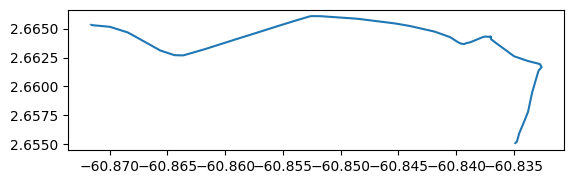

In [62]:
shapefile.plot()
#Continuaremos em Layers

# **Shape a partir da latidude e longitude**

In [65]:
# DataFrame com as principais capitais do Brasil e suas coordenadas
data = {
    'Capital': [
        'Brasília', 'São Paulo', 'Rio de Janeiro', 'Salvador', 'Belo Horizonte',
        'Fortaleza', 'Manaus', 'Curitiba', 'Recife', 'Porto Alegre'
    ],
    'Estado': [
        'Distrito Federal', 'São Paulo', 'Rio de Janeiro', 'Bahia', 'Minas Gerais',
        'Ceará', 'Amazonas', 'Paraná', 'Pernambuco', 'Rio Grande do Sul'
    ],
    'Latitude': [
        -15.7783 , -23.5505, -22.9068, -12.9777, -19.9167,
        -3.71722, -3.10194, -25.4284, -8.0476, -30.0346
    ],
    'Longitude': [
        -47.8911, -46.6333, -43.1729, -38.5014, -43.9345,
        -38.5434, -60.025, -49.2733, -34.877, -51.2177
    ]
}

capitais_df = pd.DataFrame(data)
capitais_df

,Capital,Estado,Latitude,Longitude
0,Brasília,Distrito Federal,-15.77830,-47.8911
1,São Paulo,São Paulo,-23.55050,-46.6333
2,Rio de Janeiro,Rio de Janeiro,-22.90680,-43.1729
3,Salvador,Bahia,-12.97770,-38.5014
4,Belo Horizonte,Minas Gerais,-19.91670,-43.9345
5,Fortaleza,Ceará,-3.71722,-38.5434
6,Manaus,Amazonas,-3.10194,-60.0250
7,Curitiba,Paraná,-25.42840,-49.2733
8,Recife,Pernambuco,-8.04760,-34.8770
9,Porto Alegre,Rio Grande do Sul,-30.03460,-51.2177


In [75]:
# Um GeoDataFrame precisa de um shapely object
# TODO: Criando um GeoDataFrame usando capitais_df
gdf = geopandas.GeoDataFrame(
    capitais_df,
    geometry=geopandas.points_from_xy(
        capitais_df.Longitude,
        capitais_df.Latitude
        ),
    crs="EPSG:4326"
    )

gdf.head()

,Capital,Estado,Latitude,Longitude,geometry
0,Brasília,Distrito Federal,-15.7783,-47.8911,POINT (-47.89110 -15.77830)
1,São Paulo,São Paulo,-23.5505,-46.6333,POINT (-46.63330 -23.55050)
2,Rio de Janeiro,Rio de Janeiro,-22.9068,-43.1729,POINT (-43.17290 -22.90680)
3,Salvador,Bahia,-12.9777,-38.5014,POINT (-38.50140 -12.97770)
4,Belo Horizonte,Minas Gerais,-19.9167,-43.9345,POINT (-43.93450 -19.91670)


In [70]:
import geobr

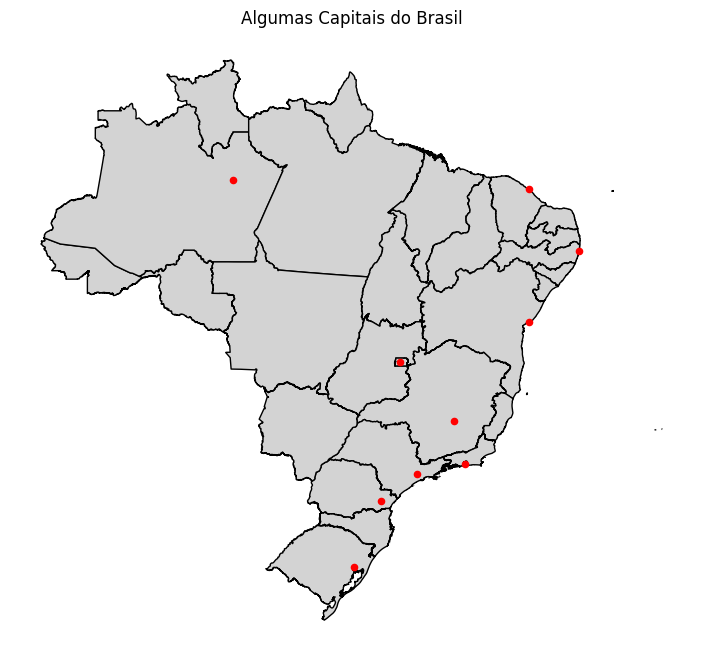

In [82]:
# Obtendo o state boundaries
brasil = geobr.read_state()

# Plot map
fig, ax = plt.subplots(figsize=(10, 8))
# criando camadas simples
# TODO: Adicionar um camada com o mapa do Brasil
brasil.plot(ax=ax, color='lightgray', edgecolor='black')

# TODO: Adicionar os pontos das capitais
gdf.plot(ax=ax, color='red', markersize=20)

# Plot
ax.set_title('Algumas Capitais do Brasil')
ax.axis('off')
plt.show()


In [83]:
gdf_br = gdf.copy()
gdf_br.head()

,Capital,Estado,Latitude,Longitude,geometry
0,Brasília,Distrito Federal,-15.7783,-47.8911,POINT (-47.89110 -15.77830)
1,São Paulo,São Paulo,-23.5505,-46.6333,POINT (-46.63330 -23.55050)
2,Rio de Janeiro,Rio de Janeiro,-22.9068,-43.1729,POINT (-43.17290 -22.90680)
3,Salvador,Bahia,-12.9777,-38.5014,POINT (-38.50140 -12.97770)
4,Belo Horizonte,Minas Gerais,-19.9167,-43.9345,POINT (-43.93450 -19.91670)


In [84]:
# Criando grafico de mapa usando o plotly com os dataframes gdf_br e brasil

import plotly.express as px

fig = px.scatter_geo(gdf_br,
                     lat=gdf_br.Latitude,
                     lon=gdf_br.Longitude,
                     hover_name="Capital",
                     projection="natural earth")

fig.update_layout(
    mapbox_style="carto-positron",
    mapbox_zoom=3,
    mapbox_center={"lat": -15, "lon": -50},
)

fig.show()

# **Selecionando dados em uma região**

In [85]:
#Obtendo os dados dos municipio do Brasil
muni = geobr.read_municipality(year=2022)
muni

,code_muni,name_muni,code_state,abbrev_state,name_state,code_region,name_region,geometry
0,1100015.0,Alta Floresta D'oeste,11.0,RO,Rondônia,1.0,Norte,"MULTIPOLYGON (((-61.96836 -12.13407, -61.96827..."
1,1100023.0,Ariquemes,11.0,RO,Rondônia,1.0,Norte,"MULTIPOLYGON (((-63.18281 -10.13892, -63.18615..."
2,1100031.0,Cabixi,11.0,RO,Rondônia,1.0,Norte,"MULTIPOLYGON (((-60.70518 -13.32474, -60.70904..."
3,1100049.0,Cacoal,11.0,RO,Rondônia,1.0,Norte,"MULTIPOLYGON (((-61.34740 -11.50562, -61.34569..."
4,1100056.0,Cerejeiras,11.0,RO,Rondônia,1.0,Norte,"MULTIPOLYGON (((-60.82417 -13.11156, -60.82289..."
...,...,...,...,...,...,...,...,...
5567,5222005.0,Vianópolis,52.0,GO,Goiás,5.0,Centro Oeste,"MULTIPOLYGON (((-48.30928 -16.84149, -48.30293..."
5568,5222054.0,Vicentinópolis,52.0,GO,Goiás,5.0,Centro Oeste,"MULTIPOLYGON (((-49.73218 -17.74154, -49.73386..."
5569,5222203.0,Vila Boa,52.0,GO,Goiás,5.0,Centro Oeste,"MULTIPOLYGON (((-47.07533 -15.06258, -47.07448..."
5570,5222302.0,Vila Propício,52.0,GO,Goiás,5.0,Centro Oeste,"MULTIPOLYGON (((-48.58701 -15.31582, -48.58952..."


In [86]:
# Minor ajustes
muni['name_muni'] = muni['name_muni'].str.lower()
muni['abbrev_state'] = muni['abbrev_state'].str.lower()
muni.head()

,code_muni,name_muni,code_state,abbrev_state,name_state,code_region,name_region,geometry
0,1100015.0,alta floresta d'oeste,11.0,ro,Rondônia,1.0,Norte,"MULTIPOLYGON (((-61.96836 -12.13407, -61.96827..."
1,1100023.0,ariquemes,11.0,ro,Rondônia,1.0,Norte,"MULTIPOLYGON (((-63.18281 -10.13892, -63.18615..."
2,1100031.0,cabixi,11.0,ro,Rondônia,1.0,Norte,"MULTIPOLYGON (((-60.70518 -13.32474, -60.70904..."
3,1100049.0,cacoal,11.0,ro,Rondônia,1.0,Norte,"MULTIPOLYGON (((-61.34740 -11.50562, -61.34569..."
4,1100056.0,cerejeiras,11.0,ro,Rondônia,1.0,Norte,"MULTIPOLYGON (((-60.82417 -13.11156, -60.82289..."


In [87]:
muni.crs

<Geographic 2D CRS: EPSG:4674>
Name: SIRGAS 2000
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: Latin America - Central America and South America - onshore and offshore. Brazil - onshore and offshore.
- bounds: (-122.19, -59.87, -25.28, 32.72)
Datum: Sistema de Referencia Geocentrico para las AmericaS 2000
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [88]:
# AVISO: Cuidado com o CRS
s = muni[(muni['abbrev_state'] == 'rr') & (muni['name_muni'] == 'boa vista')]

# TODO: Obter latitude e longitude de s
print(s['geometry'].centroid.y)
print(s['geometry'].centroid.x)

138    3.117894
dtype: float64
138   -60.717954
dtype: float64


<ipython-input-88-4433490986bf>:5: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.


<ipython-input-88-4433490986bf>:6: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.




In [89]:
muni['latitude']  = muni['geometry'].apply(lambda point: point.centroid.y)
muni['longitude'] = muni['geometry'].apply(lambda point: point.centroid.x)

muni.head()


,code_muni,name_muni,code_state,abbrev_state,name_state,code_region,name_region,geometry,latitude,longitude
0,1100015.0,alta floresta d'oeste,11.0,ro,Rondônia,1.0,Norte,"MULTIPOLYGON (((-61.96836 -12.13407, -61.96827...",-12.470096,-62.274659
1,1100023.0,ariquemes,11.0,ro,Rondônia,1.0,Norte,"MULTIPOLYGON (((-63.18281 -10.13892, -63.18615...",-9.951894,-62.957174
2,1100031.0,cabixi,11.0,ro,Rondônia,1.0,Norte,"MULTIPOLYGON (((-60.70518 -13.32474, -60.70904...",-13.474891,-60.639858
3,1100049.0,cacoal,11.0,ro,Rondônia,1.0,Norte,"MULTIPOLYGON (((-61.34740 -11.50562, -61.34569...",-11.301239,-61.324740
4,1100056.0,cerejeiras,11.0,ro,Rondônia,1.0,Norte,"MULTIPOLYGON (((-60.82417 -13.11156, -60.82289...",-13.203514,-61.260916


In [90]:
# minor ajustes
novo_df['UF_LPI'] = novo_df['UF_LPI'].str.lower()
novo_df['MUN_LPI'] = novo_df['MUN_LPI'].str.lower()
novo_df.head()

,UF_LPI,MUN_LPI,SEXO,IDADE,ANO_IS,OBITO
0,ac,acrelândia,M,16,2020,SIM
1,ac,plácido de castro,M,21,2000,NÃO
2,am,urucurituba,F,16,2003,NÃO
3,am,presidente figueiredo,F,17,1998,NÃO
4,am,codajás,M,21,2019,NÃO


# **Merge dos dados em novo_df e muni**

In [92]:
# Contabiliza o número de valores na coluna MUN_LPI em novo_df_rr e crie um
# novo dataframe contendo as colunas MUN_LPI, UF_LPI e  count como resultado

mun_lpi_count = novo_df.groupby(['MUN_LPI', 'UF_LPI'])['MUN_LPI'].count().reset_index(name='count')
mun_lpi_count.sort_values('UF_LPI')



,MUN_LPI,UF_LPI,count
408,plácido de castro,ac,1
3,acrelândia,ac,1
294,manaquiri,am,2
422,presidente figueiredo,am,2
34,anori,am,2
...,...,...,...
207,gurupi,to,1
533,são salvador do tocantins,to,1
427,recursolândia,to,2
101,campos lindos,to,10


In [93]:
# Compara mun_lpi_count usando a coluna UF_LPI e MUN_LPI com muni usando a
# coluna abbrev_state e name_muni

merged_df = pd.merge(mun_lpi_count, muni, left_on=['UF_LPI', 'MUN_LPI'], right_on=['abbrev_state', 'name_muni'], how='left')
merged_df.head()


,MUN_LPI,UF_LPI,count,code_muni,name_muni,code_state,abbrev_state,name_state,code_region,name_region,geometry,latitude,longitude
0,abadiânia,go,1,5200100.0,abadiânia,52.0,go,Goiás,5.0,Centro Oeste,"MULTIPOLYGON (((-48.67016 -16.28642, -48.67023...",-16.186637,-48.713416
1,acaiaca,mg,4,3100401.0,acaiaca,31.0,mg,Minas Gerais,3.0,Sudeste,"MULTIPOLYGON (((-43.12075 -20.43496, -43.12246...",-20.399797,-43.101286
2,acará,pa,1,1500206.0,acará,15.0,pa,Pará,1.0,Norte,"MULTIPOLYGON (((-48.37288 -1.48996, -48.38821 ...",-2.035344,-48.411450
3,acrelândia,ac,1,1200013.0,acrelândia,12.0,ac,Acre,1.0,Norte,"MULTIPOLYGON (((-67.07596 -10.20242, -67.00239...",-9.933866,-66.950130
4,adrianópolis,pr,2,4100202.0,adrianópolis,41.0,pr,Paraná,4.0,Sul,"MULTIPOLYGON (((-48.73077 -24.86834, -48.72862...",-24.783472,-48.821244


In [94]:
# TODO: Obtendo o shape
merged_df.shape

(589, 13)

In [95]:
# Criando um grafico de mapa e bolhas usando a coluna count, latitude e longitude

fig = px.scatter_geo(merged_df,
                     lat=merged_df.latitude,
                     lon=merged_df.longitude,
                     size="count",
                     hover_name="name_muni",
                     # TODO: Adicionar o nome do Estado
                     hover_data =["name_state"],
                     title='Casos de Febre Amarela no Brasil',
                     projection="natural earth"
                     )

fig.update_layout(
    geo=dict(
        showland=True,
        landcolor="rgb(212, 212, 212)",
        subunitcolor="rgb(255, 255, 255)",
        countrycolor="rgb(255, 255, 255)",
        showlakes=True,
        lakecolor="rgb(255, 255, 255)",
        showsubunits=True,
        showcountries=True,
        resolution=50,
        scope='south america',  # Focus on South America
        projection=dict(
            type='mercator',  # Use Mercator projection
            scale=2.5  # Adjust scale as needed
        )
    ),
    margin={"r":0,"t":30,"l":0,"b":0}
)

fig.show()


In [98]:
# Criando um grafico de mapa e bolhas usando a coluna count, latitude e longitude
# Adição de atributos

fig = px.scatter_geo(merged_df,
                     lat=merged_df.latitude,
                     lon=merged_df.longitude,
                     size="count",
                     hover_name="name_muni",
                     hover_data =["name_state"],
                     title='Casos de Febre Amarela no Brasil',
                     projection="natural earth"
                     )

fig.update_layout(
    geo=dict(
        showland=True,
        landcolor="rgb(212, 212, 212)",
        subunitcolor="rgb(255, 255, 255)",
        countrycolor="rgb(255, 255, 255)",
        showlakes=True,
        lakecolor="rgb(255, 255, 255)",
        showsubunits=True,
        showcountries=True,
        resolution=50,
        scope='south america',  # Focus on South America
        projection=dict(
            type='mercator',  # Use Mercator projection
            scale=2.5  # Adjust scale as needed
        )
    ),
    margin={"r":0,"t":30,"l":0,"b":0}
)

# TODO: Adicionar atributos
fig.update_geos(
    resolution=50,
    showcountries=True,
    countrycolor="black",
    showsubunits=True,
    subunitcolor="blue",
    showland=True,
    landcolor="white",
    showlakes=True,
    lakecolor="blue",
    showrivers=True,
    rivercolor="blue",
)

fig.show()


In [99]:
# criando um grafico de mapa e bolhas usando a coluna count, latitude e longitude
# https://plotly.com/python/map-configuration/

# Visão ortográfica
fig = px.scatter_geo(merged_df,
                     lat=merged_df.latitude,
                     lon=merged_df.longitude,
                     size="count",
                     hover_name="name_muni",
                     hover_data =["name_state"],
                     title='Casos de Febre Amarela no Brasil',
                     projection="natural earth"
                     )

fig.update_layout(
    geo=dict(
        showland=True,
        landcolor="rgb(212, 212, 212)",
        subunitcolor="rgb(255, 255, 255)",
        countrycolor="rgb(255, 255, 255)",
        showlakes=True,
        lakecolor="rgb(255, 255, 255)",
        showsubunits=True,
        showcountries=True,
        resolution=50,
        projection=dict(
            type='mercator',  # Use Mercator projection
            scale=2.5  # Adjust scale as needed
        )
    ),
    margin={"r":0,"t":30,"l":0,"b":0}
)

# TODO: Projeção de visualização
fig.update_geos(
    projection_type="orthographic"
)

fig.show()


In [ ]:
# Criando uma grafico de mapa e bolhas usando a coluna count, latitude e longitude

fig = px.scatter_geo(merged_df,
                     lat=merged_df.latitude,
                     lon=merged_df.longitude,
                     size="count",
                     hover_name="name_muni",
                     hover_data =["name_state"],
                     title='Casos de Febre Amarela no Brasil',
                     projection="natural earth"
                     )

fig.update_layout(
    geo=dict(
        showland=True,
        landcolor="rgb(212, 212, 212)",
        subunitcolor="rgb(255, 255, 255)",
        countrycolor="rgb(255, 255, 255)",
        showlakes=True,
        lakecolor="rgb(255, 255, 255)",
        showsubunits=True,
        showcountries=True,
        resolution=50,
        scope='south america',  # Focus on South America
        projection=dict(
            type='mercator',  # Use Mercator projection
            scale=2.5  # Adjust scale as needed
        )
    ),
    margin={"r":0,"t":30,"l":0,"b":0}
)

# Adicionando linhas de Latitude e Longitude
fig.update_geos(
    lataxis=
)


fig.show()


---
# **FIM da Aula 003**

---

# Desafio:
Contabilize a média de idade na coluna IDADE para cada municipio em novo_df e plot um mapa de bolhas, somente para o estado de Roraima

In [ ]:
# TODO

primeira coisa
pegar o data frame q ja temos com municipios lat long tude e catar ele pra ca

filtrar somente os casos acontecidos em RR

gerar um dataframe desse filtro

plotar isso tudo num mapa, plotar as bolhas

e estas bolhas serão a IDADE MÉDIA

